In [ ]:
!pip install torchvision matplotlib
import torch as t
import torch.nn as tnn
import torchvision as tv
from torchvision.datasets import OxfordIIITPet as OXPet
import torchvision.transforms as tr
from torch.utils.data import DataLoader as DL
import matplotlib.pyplot as mplt
import numpy as nmp
from PIL import Image as Img
dev = "cuda" if t.cuda.is_available() else "cpu"
print("Device:", dev)

Device: cuda


dataset

In [ ]:
img_transform = tr.Compose([
    tr.Resize((256,256)),
    tr.ToTensor(),
    tr.Normalize([0.5,0.5,0.5],[0.5,0.5,0.5])
])

mask_transform = tr.Compose([
    tr.Resize((256,256)),
    tr.PILToTensor()
])

only cats

In [ ]:
class PetData(t.utils.data.Dataset):
    def __init__(self, split="trainval"):
        self.data = OXPet(
            root="data",
            split=split,
            target_types="segmentation",
            download=True
        )

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        image, msk = self.data[idx]

        image = img_transform(image)
        msk = mask_transform(msk)

        # Convert (1=pet, 2=bg, 3=border) → binary
        msk = msk - 1
        msk = (msk == 0).float()   # 1 = pet, 0 = background

        return image, msk

In [ ]:
train_data = PetData("trainval")
test_data = PetData("test")

train_dl = DL(train_data, batch_size=8, shuffle=True)
test_dl = DL(test_data, batch_size=8)

encoder-decoder

In [ ]:
class BinSegNet(tnn.Module):
    def __init__(self):
        super().__init__()

        # Encoder
        self.encoder = tnn.Sequential(
        tnn.Conv2d(3, 16, 3, padding=1),
        tnn.BatchNorm2d(16),
        tnn.ReLU(),
        tnn.MaxPool2d(2),

        tnn.Conv2d(16, 32, 3, padding=1),
        tnn.BatchNorm2d(32),
        tnn.ReLU(),
        tnn.MaxPool2d(2)
        )

        # Decoder
        self.decoder = tnn.Sequential(
            tnn.ConvTranspose2d(32, 16, 2, stride=2),
            tnn.ReLU(),

            tnn.ConvTranspose2d(16, 1, 2, stride=2)
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

net = BinSegNet().to(dev)

loss

In [ ]:
loss_fn = tnn.BCEWithLogitsLoss(
    pos_weight=t.tensor([10.0]).to(dev)
 )
optim = t.optim.Adam(net.parameters(), lr=1e-3)

training

In [ ]:
EPOCHS = 20

for ep in range(EPOCHS):
    net.train()
    epoch_loss = 0

    for img_b, msk_b in train_dl:
        img_b = img_b.to(dev)
        msk_b = msk_b.to(dev)

        out = net(img_b)

        loss = loss_fn(out, msk_b)

        optim.zero_grad()
        loss.backward()
        optim.step()

        epoch_loss += loss.item()

    print(f"Epoch {ep+1}, Loss: {epoch_loss/len(train_dl):.4f}")

Epoch 1, Loss: 1.7226
Epoch 2, Loss: 1.5998
Epoch 3, Loss: 1.5729
Epoch 4, Loss: 1.5534
Epoch 5, Loss: 1.5491
Epoch 6, Loss: 1.5357
Epoch 7, Loss: 1.5341
Epoch 8, Loss: 1.5192
Epoch 9, Loss: 1.5176
Epoch 10, Loss: 1.5089
Epoch 11, Loss: 1.5064
Epoch 12, Loss: 1.4902
Epoch 13, Loss: 1.4800
Epoch 14, Loss: 1.4643
Epoch 15, Loss: 1.4581
Epoch 16, Loss: 1.4509
Epoch 17, Loss: 1.4448
Epoch 18, Loss: 1.4321
Epoch 19, Loss: 1.4276
Epoch 20, Loss: 1.4232


In [ ]:
print("Original image:", img_b.cpu().permute(1,2,0).numpy().shape)
print("Tensor input:", img_t.shape)
print("Prediction:", pred.shape)

RuntimeError: permute(sparse_coo): number of dimensions in the tensor input does not match the length of the desired ordering of dimensions i.e. input.dim() = 4 is not equal to len(dims) = 3

visualize

In [ ]:
def show_results(image, msk, pred):
    image = image.permute(1,2,0).cpu().numpy()

    # Ensure correct shapes
    msk = msk.cpu().numpy()
    pred = pred.cpu().numpy()

    mplt.figure(figsize=(12,4))

    mplt.subplot(1,3,1)
    mplt.title("Image")
    mplt.imshow(image)

    mplt.subplot(1,3,2)
    mplt.title("Ground Truth")
    mplt.imshow(msk, cmap='gray')

    mplt.subplot(1,3,3)
    mplt.title("Prediction")
    mplt.imshow(pred, cmap='gray')

    mplt.show()

Test

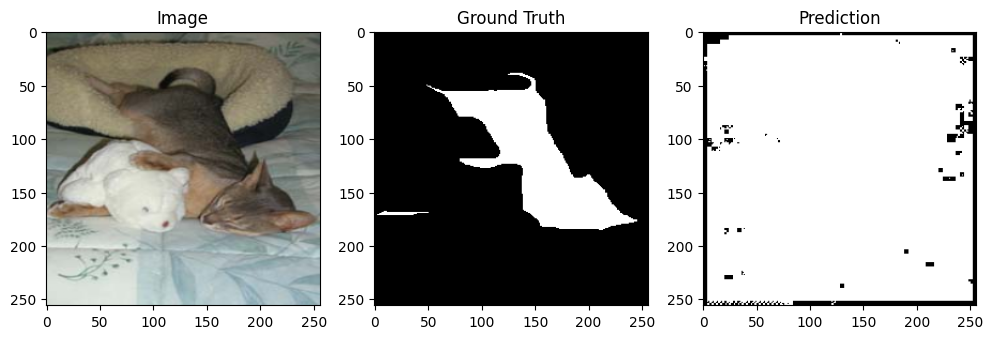

In [ ]:
net.eval()

with t.no_grad():
    image, msk = test_data[5]

    image_input = image.unsqueeze(0).to(dev)

    out = net(image_input)

    pred = t.sigmoid(out)
    pred = (pred > 0.5).float()

    # 🔥 FIX HERE
    pred = pred.squeeze(0).squeeze(0)   # (1,1,H,W) → (H,W)
    msk = msk.squeeze(0)              # (1,H,W) → (H,W)

    show_results(image, msk, pred)

IOU

In [ ]:
def calc_iou(pred, msk):
    # Ensure same device (move to CPU for safety)
    pred = pred.squeeze().cpu()
    msk = msk.squeeze().cpu()

    # Convert to boolean
    pred = pred > 0
    msk = msk > 0

    intersection = (pred & msk).sum().item()
    union = (pred | msk).sum().item()

    return intersection / union if union != 0 else 0

In [ ]:
iou_val = calc_iou(pred, msk)
print("IoU:", iou_val)

IoU: 0.15768541800193922


In [ ]:
from google.colab import files as gfiles
uploaded_files = gfiles.upload()

Saving images-2.jpeg to images-2 (2).jpeg


In [ ]:
img_in = Img.open(list(uploaded_files.keys())[0]).convert("RGB")
img_resized = img_in.resize((256,256))

img_t = img_transform(img_in).unsqueeze(0).to(dev)

net.eval()
with t.no_grad():
    out = net(img_t)
    pred = t.sigmoid(out)
    pred = (pred > 0.5).float()

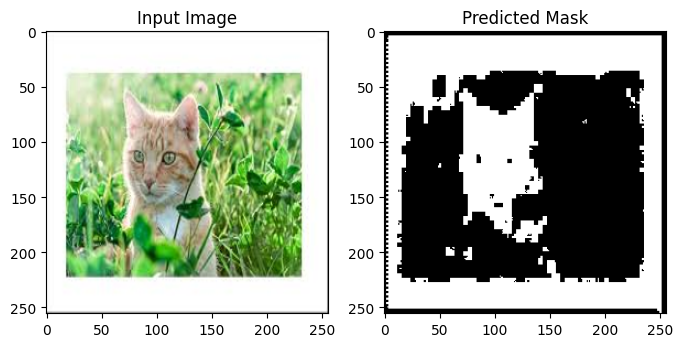

In [ ]:
mplt.figure(figsize=(8,4))

mplt.subplot(1,2,1)
mplt.title("Input Image")
mplt.imshow(img_resized)

mplt.subplot(1,2,2)
mplt.title("Predicted Mask")
mplt.imshow(pred.squeeze().cpu(), cmap='gray')

mplt.show()

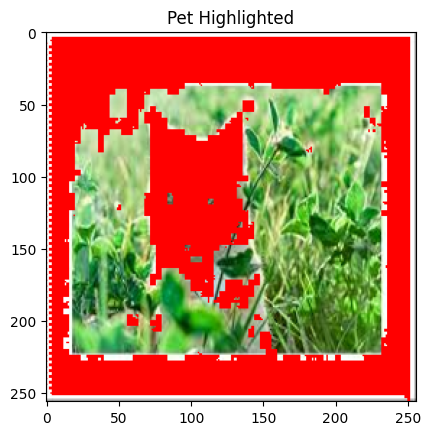

In [ ]:
msk_np = pred.squeeze().cpu().numpy()   # ✅ FIX

img_np = nmp.array(img_resized)

overlay = img_np.copy()
overlay[msk_np == 1] = [255, 0, 0]

mplt.imshow(overlay)
mplt.title("Pet Highlighted")
mplt.show()